# Explore here

In [ ]:
import pandas as pd

# Cargar el archivo CSV
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv')

# Mostrar las primeras filas
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


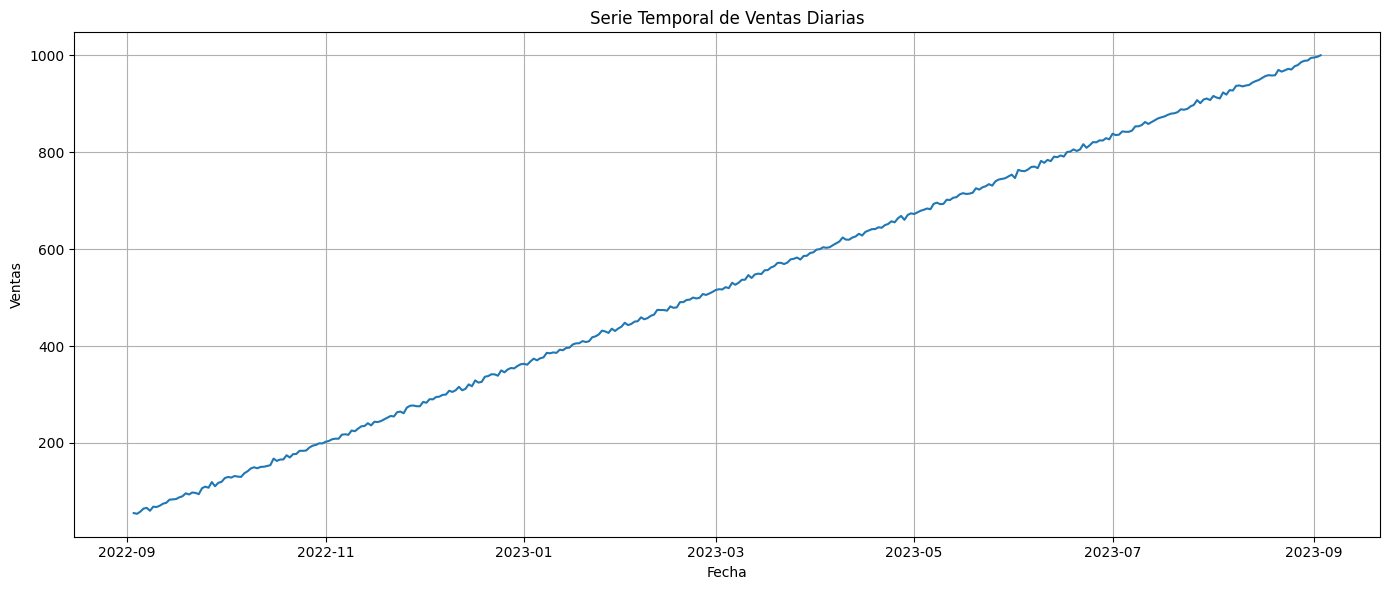

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarnos de que 'date' sea tipo datetime y establecer como índice
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Re-muestrear a frecuencia diaria (promedio por día)
daily_sales = df.resample('D').mean()

# Graficar la serie temporal
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x=daily_sales.index, y='sales')
plt.title('Serie Temporal de Ventas Diarias')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 42.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 36.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from statsmodels.tsa.stattools import adfuller

# Aplicamos la prueba ADF sobre la serie de ventas diarias
result = adfuller(daily_sales['sales'].dropna())

# Mostrar resultados
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Valor crítico {key}: {value}")


ADF Statistic: 0.5454141937063742
p-value: 0.9861899815311063
Valor crítico 1%: -3.4490648539347544
Valor crítico 5%: -2.8697861692116478
Valor crítico 10%: -2.5711631253228306


In [7]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")  # Para evitar warnings molestos

# Diferenciación de orden 1 para estacionarizar
diff_sales = daily_sales['sales'].diff().dropna()

# Entrenar modelo ARIMA inicial con parámetros base (pueden refinarse)
model = ARIMA(daily_sales['sales'], order=(1, 1, 1))
fitted_model = model.fit()

# Resumen del modelo
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  366
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1049.226
Date:                Fri, 02 May 2025   AIC                           2104.453
Time:                        23:34:06   BIC                           2116.152
Sample:                    09-03-2022   HQIC                          2109.102
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.000   2025.703      0.000       0.999       1.001
ma.L1         -0.9996      0.440     -2.271      0.023      -1.862      -0.137
sigma2        18.1480      8.139      2.230      0.0

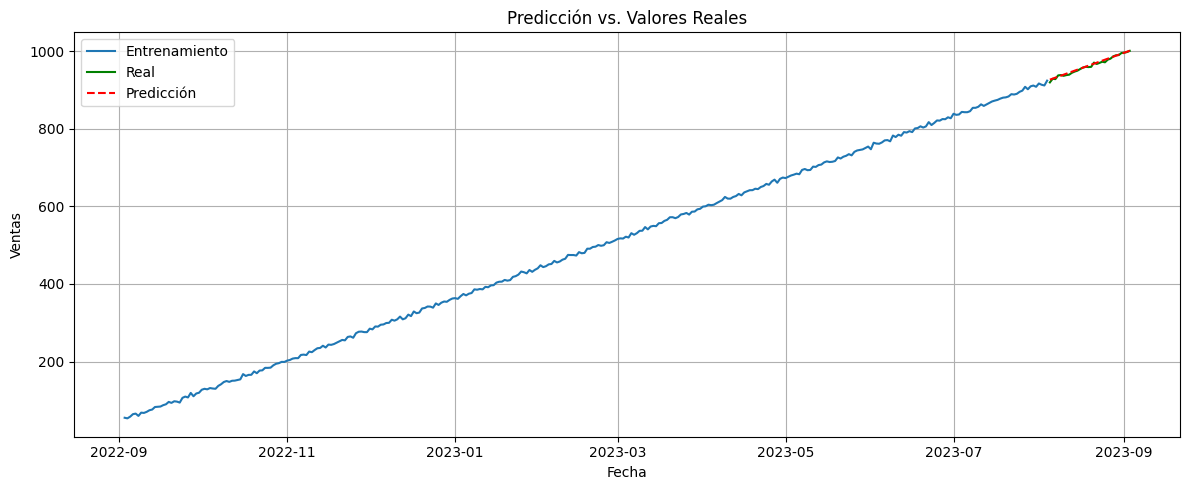

MAE: 2.55
RMSE: 3.13


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Dividir en train y test (últimos 30 días como test)
train = daily_sales[:-30]
test = daily_sales[-30:]

# Reentrenar ARIMA sobre el conjunto de entrenamiento
model = ARIMA(train['sales'], order=(1, 1, 1))
fitted_model = model.fit()

# Predecir sobre el conjunto de test
forecast = fitted_model.forecast(steps=30)
forecast.index = test.index  # sincronizamos los índices

# Graficar comparación
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['sales'], label='Entrenamiento')
plt.plot(test.index, test['sales'], label='Real', color='green')
plt.plot(forecast.index, forecast, label='Predicción', color='red', linestyle='--')
plt.title('Predicción vs. Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Métricas de evaluación
mae = mean_absolute_error(test['sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['sales'], forecast))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
